In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.construct as ct
import OptimalBattery.util as ut
import OptimalBattery.estimate as et
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import os
import OptimalBattery.plot as plot
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [2]:
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')


# start with some U_true, in this simulation its 5 parcels
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]

   
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)


In [3]:
U_true_5 = pt.from_numpy(U_true_5).to(device=device, dtype=pt.float64)

# make a collapsed U_true where one region is 1 and the rest are 0
collapsed_U_true = sim.collapse_U(U_true_5, target_parcels_indices=[4])

In [4]:
# constants
battery_sizes = [2,4,8,16,24]
n_batteries = 1000 # only for multi
num_task_lib = 100 # shared
n_parcels = 5 # shared
base_noise_list = [4,8,20,32,100]
n_sim = 10 # shared
threshold_list = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,0.82,0.84,0.86,0.88, 0.9, 0.95, 0.99]


In [5]:
def get_confusion_stats(U_true, U_pred, roi_index=0):
    """
    Computes TP, FN, FP, TN from hard parcellations for a binary region of interest (ROI).
    
    Both inputs should be shape (2, P) or (K, P), where one row is ROI and rest is background.

    Args:
        U_true (torch.Tensor): Ground truth (2, P)
        U_pred (torch.Tensor): Predicted (2, P)
        roi_index (int): Index of the ROI row (default=0)

    Returns:
        dict: TP, FN, FP, TN as counts
    """
    if len(U_pred.shape) == 3:
        U_pred = U_pred[0]

    true_mask = U_true[roi_index].cpu().numpy().astype(bool)
    pred_mask = U_pred[roi_index].cpu().numpy().astype(bool)

    TP = np.logical_and(true_mask, pred_mask).sum()
    FN = np.logical_and(true_mask, ~pred_mask).sum()
    FP = np.logical_and(~true_mask, pred_mask).sum()
    TN = np.logical_and(~true_mask, ~pred_mask).sum()

    return {'TP': TP, 'FN': FN, 'FP': FP, 'TN': TN}

def sim_parcellation(num_task_lib = 100,
                     n_parcels = 5,
                     metrics = ['random'],
                     U_true = None,
                     battery_sizes = [3,4,6,8,10,14,18,24,28],
                     n_batteries = 100,
                     base_noise = 2,
                     collapsed_U_true = None,
                     n_sim = 50,
                     seed = None):
    """ Single simulation for the parcellation estimation
    Args:
        num_task_lib: Number of tasks in the library
        n_parcels: Number of parcels in the U_true
        U_true: ground truth parcellation
        battery_sizes: List of battery sizes to test
        n_batteries: Number of batteries to sample for each battery size
        base_noise: Base noise level
        collapsed_U_true: Collapsed U_true for the single region analysis
        n_sim: Number of simulations to run
        seed: Random seed for reproducibility
    returns:
        results_df: DataFrame with the results of the simulations
    """
    

    metrics = metrics
    max_battery_size = max(battery_sizes)

    results_df = pd.DataFrame()

    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")
        for n in range(n_sim):
            if seed is not None:
                rng = np.random.default_rng(seed=seed)
            else:
                rng = np.random.default_rng()
            V_lib = rng.normal(0, 1, (num_task_lib, n_parcels))
            V_lib = V_lib - V_lib.mean(axis=0, keepdims=True)
            G_lib = V_lib @ V_lib.T
            V_lib = pt.tensor(V_lib, device=device, dtype=pt.float64)

            D = ct.build_combinations(G_lib=G_lib, strategy='random', n_batteries=n_batteries,
                                      n_tasks=n_task, replacement=False, rest_idx=None, seed=seed)

            for metric in metrics:
                D_best = ct.choose_combination(D, metric)
                top_comb = D_best['combination'].values[0]

                if n_task == 2:
                    top_comb = sim.find_max_contrast_against_all(Vs=V_lib, region_idx=4)

                V_battery = V_lib[top_comb, :]
                V_battery = ut.center_matrix(V_battery, axis=0)

                Y_battery = V_battery @ U_true
                weighted_noise_std = sim.get_weighted_noise_std(n_task, max_battery_size, base_noise)
                rng = np.random.default_rng(seed)
                noise = rng.normal(0, weighted_noise_std, Y_battery.shape)
                noise = pt.tensor(noise, dtype=pt.float64, device=Y_battery.device)
                Y_battery = Y_battery + noise
                Y_battery = ut.center_matrix(Y_battery, axis=0)
                Y_battery = ut.normalize_matrix(Y_battery, axis=0)

                U_hats = et.estimate_Us(Y_battery, V_battery, method='correlation', hard=True)

                if collapsed_U_true is not None:
                    U_eval = sim.collapse_U(U_hats, target_parcels_indices=[4])
                    stats = get_confusion_stats(collapsed_U_true, U_eval, roi_index=0)
                    dice = sim.get_dice_binary(collapsed_U_true, U_eval)
                else:
                    U_eval = U_hats
                    stats = get_confusion_stats(U_true, U_eval, roi_index=4)
                    dice = sim.get_dice_binary(U_true, U_eval)

                TP = stats['TP']
                FN = stats['FN']
                FP = stats['FP']
                TN = stats['TN']
                TPR = TP / (TP + FN + 1e-8)
                FPR = FP / (FP + TN + 1e-8)

                D_ev = pd.DataFrame({
                    'n_task': [n_task],
                    'metric': [metric],
                    'dice': [dice],
                    'TP': [TP],
                    'FN': [FN],
                    'FP': [FP],
                    'TN': [TN],
                    'TPR': [TPR],
                    'FPR': [FPR],
                })

                results_df = pd.concat([results_df, D_ev], axis=0)

    return results_df

def sim_single_contrast(num_task_lib=100,
                        n_parcels=5,
                        U_true=None,
                        base_noise=5,
                        max_battery_size=28,
                        thresholds=[0.1, 0.2, 0.3, 0.4, 0.5],
                        U_true_collapsed=None,
                        n_sim=50,
                        seed=None):
    """ Single simulation for the single contrast parcellation estimation
    Args:
        num_task_lib: Number of tasks in the library
        n_parcels: Number of parcels in the U_true
        U_true: ground truth parcellation
        base_noise: Base noise level
        max_battery_size: Maximum battery size (from the list of battery sizes in the multi-task simulation)
        thresholds: List of thresholds to test
        U_true_collapsed: Collapsed U_true for the single region analysis
        n_sim: Number of simulations to run
        seed: Random seed for reproducibility
    returns:
    """
    

    results_df = pd.DataFrame()
    for n in range(n_sim):
        if seed is not None:
            rng = np.random.default_rng(seed=seed)
        else:
            rng = np.random.default_rng()
        V_lib = rng.normal(0, 1, (num_task_lib, n_parcels))
        V_lib = V_lib - V_lib.mean(axis=0, keepdims=True)
        V_lib = pt.tensor(V_lib, device=device, dtype=pt.float64)

        max_idx, min_idx = sim.find_max_contrast_against_all(V_lib, 4)
        combination = [max_idx, min_idx]

        V_localizer = V_lib[combination, :]
        V_localizer = ut.center_matrix(V_localizer, axis=0)

        Y_localizer = V_localizer @ U_true
        weighted_noise_std = sim.get_weighted_noise_std(2, max_battery_size, base_noise)
        rng = np.random.default_rng(seed)
        noise = rng.normal(0, weighted_noise_std, Y_localizer.shape)
        noise = pt.tensor(noise, dtype=pt.float64, device=Y_localizer.device)
        Y_localizer = Y_localizer + noise
        # Y_localizer = ut.center_matrix(Y_localizer, axis=0)
        # Y_localizer = ut.normalize_matrix(Y_localizer, axis=0)

        for threshold in thresholds:
            contrast = sim.make_thresholded_contrast(Y_localizer[0, :], Y_localizer[1, :], threshold)
            stats = get_confusion_stats(U_true_collapsed, contrast, roi_index=0)
            dice = sim.get_dice_binary(collapsed_U_true, contrast)

            TP = stats['TP']
            FP = stats['FP']
            FN = stats['FN']
            TN = stats['TN']

            dice = 2 * TP / (2 * TP + FP + FN + 1e-8)
            TPR = TP / (TP + FN + 1e-8)  # avoid division by zero
            FPR = FP / (FP + TN + 1e-8)

            results_df = pd.concat([results_df, pd.DataFrame({
                'threshold': [threshold],
                'TPR': [TPR],
                'FPR': [FPR],
                'dice':[dice],
                'TP': [TP],
                'FN': [FN],
                'FP': [FP],
                'TN': [TN]

            })], axis=0)

    return results_df

In [6]:
results_all = []

for noise in base_noise_list:
    D_multi = sim_parcellation(
        num_task_lib=num_task_lib,
        n_parcels=n_parcels,
        metrics=['inverse_trace_mc'],
        U_true=U_true_5,
        battery_sizes=battery_sizes,
        n_batteries=n_batteries,
        base_noise=noise,
        n_sim=n_sim,
        collapsed_U_true=collapsed_U_true, seed=0
    )

    D_random = sim_parcellation(
        num_task_lib=num_task_lib,
        n_parcels=n_parcels,
        metrics=['random'],
        U_true=U_true_5,
        battery_sizes=battery_sizes,
        n_batteries=n_batteries,
        base_noise=noise,
        n_sim=n_sim,
        collapsed_U_true=collapsed_U_true, seed=0
    )

    D_single = sim_single_contrast(
        num_task_lib=num_task_lib,
        n_parcels=n_parcels,
        U_true=U_true_5,
        base_noise=noise,
        max_battery_size=max(battery_sizes),
        thresholds=threshold_list,
        U_true_collapsed=collapsed_U_true,
        n_sim=n_sim, seed=0
    )

    D_multi['base_noise'] = noise
    D_multi['strategy'] = 'optimized'
    D_random['base_noise'] = noise
    D_random['strategy'] = 'random'
    D_single['base_noise'] = noise
    D_single['strategy'] = 'single'

    results_all.append((D_multi, D_random, D_single, noise))


Processing battery size: 2
Processing battery size: 4
Processing battery size: 8
Processing battery size: 16
Processing battery size: 24
Processing battery size: 2
Processing battery size: 4
Processing battery size: 8
Processing battery size: 16
Processing battery size: 24
Processing battery size: 2
Processing battery size: 4
Processing battery size: 8
Processing battery size: 16
Processing battery size: 24
Processing battery size: 2
Processing battery size: 4
Processing battery size: 8
Processing battery size: 16
Processing battery size: 24
Processing battery size: 2
Processing battery size: 4
Processing battery size: 8
Processing battery size: 16
Processing battery size: 24
Processing battery size: 2
Processing battery size: 4
Processing battery size: 8
Processing battery size: 16
Processing battery size: 24
Processing battery size: 2
Processing battery size: 4
Processing battery size: 8
Processing battery size: 16
Processing battery size: 24
Processing battery size: 2
Processing bat

C:\Users\barafat\AppData\Local\Temp\ipykernel_3860\4184130758.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Set1', len(n_tasks))


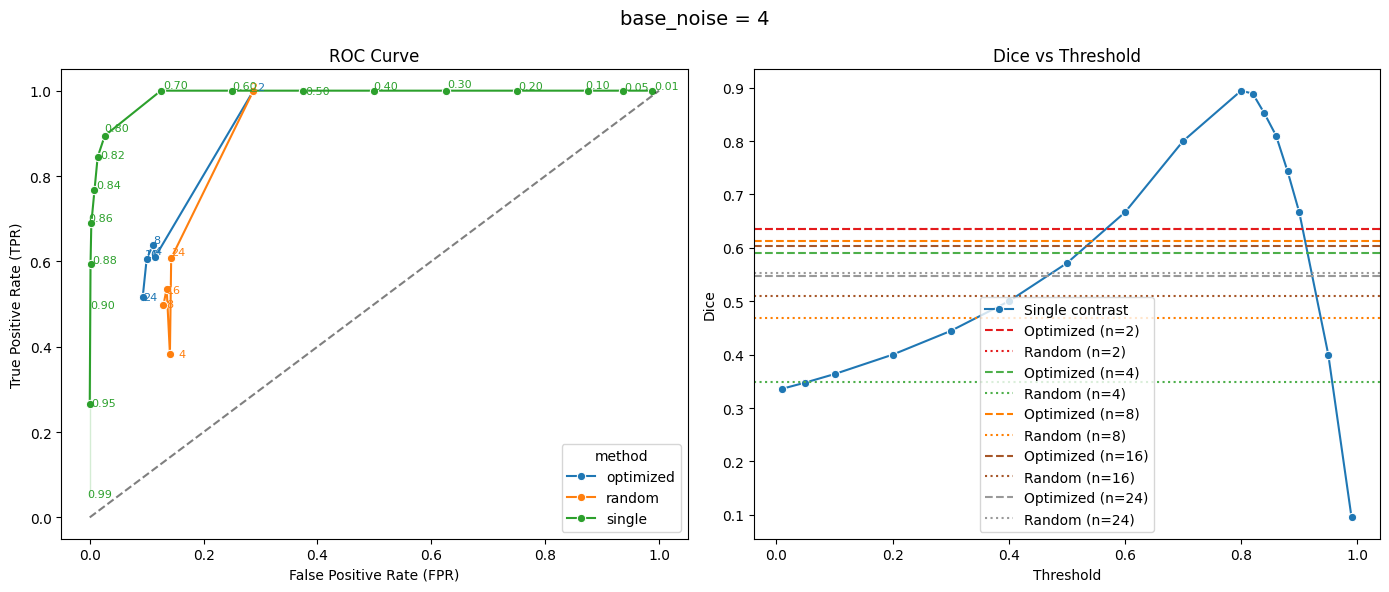

C:\Users\barafat\AppData\Local\Temp\ipykernel_3860\4184130758.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Set1', len(n_tasks))


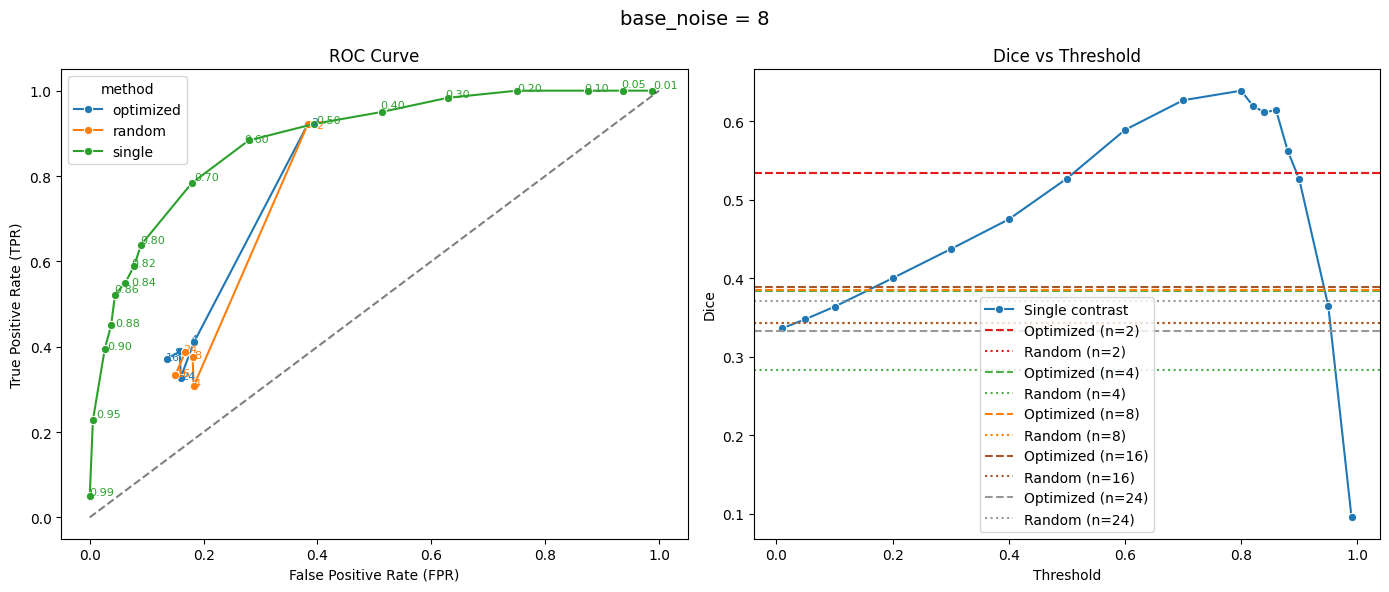

C:\Users\barafat\AppData\Local\Temp\ipykernel_3860\4184130758.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Set1', len(n_tasks))


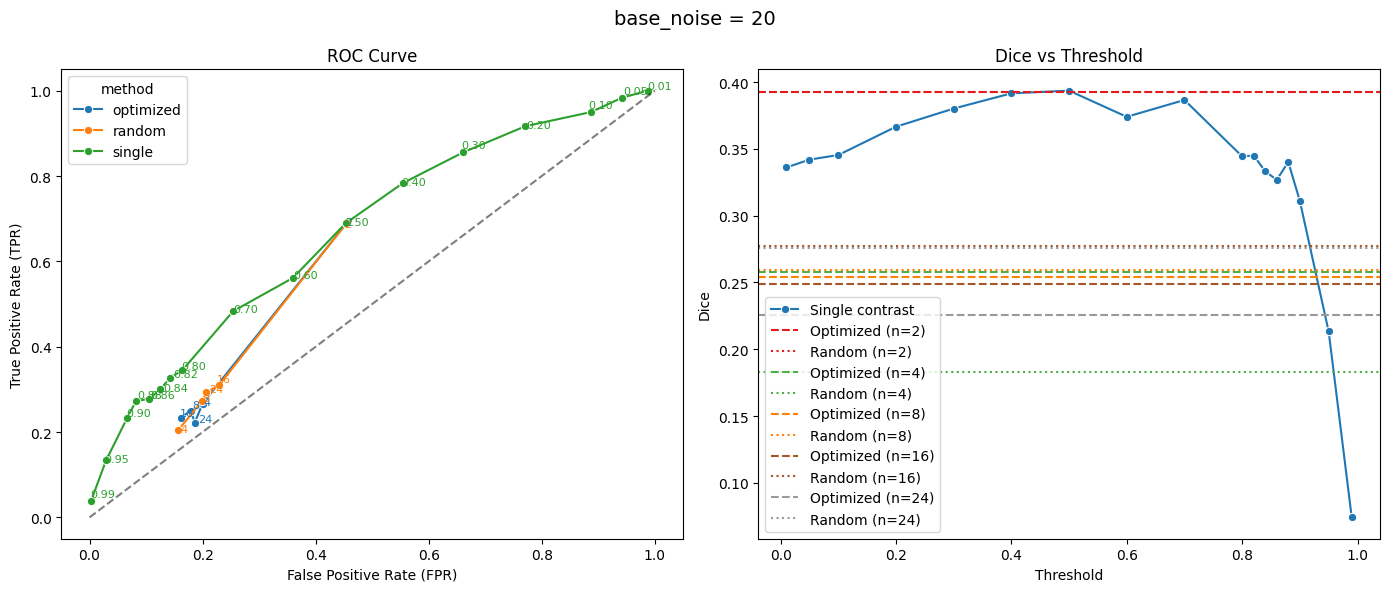

C:\Users\barafat\AppData\Local\Temp\ipykernel_3860\4184130758.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Set1', len(n_tasks))


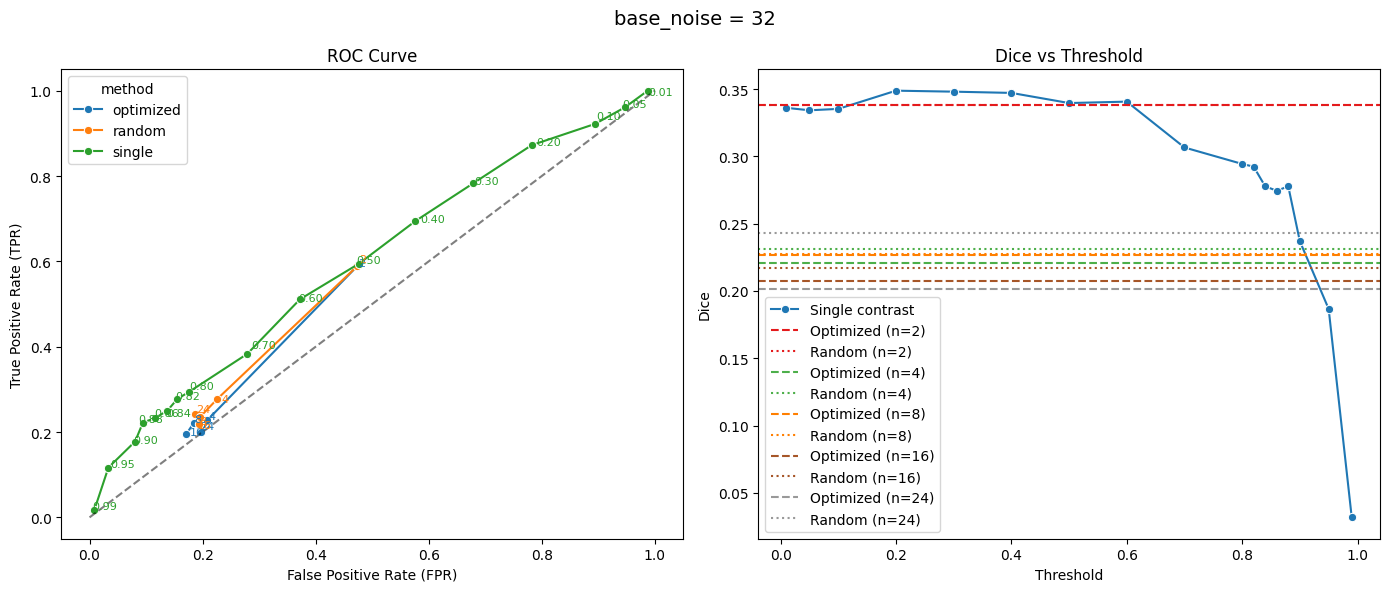

C:\Users\barafat\AppData\Local\Temp\ipykernel_3860\4184130758.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Set1', len(n_tasks))


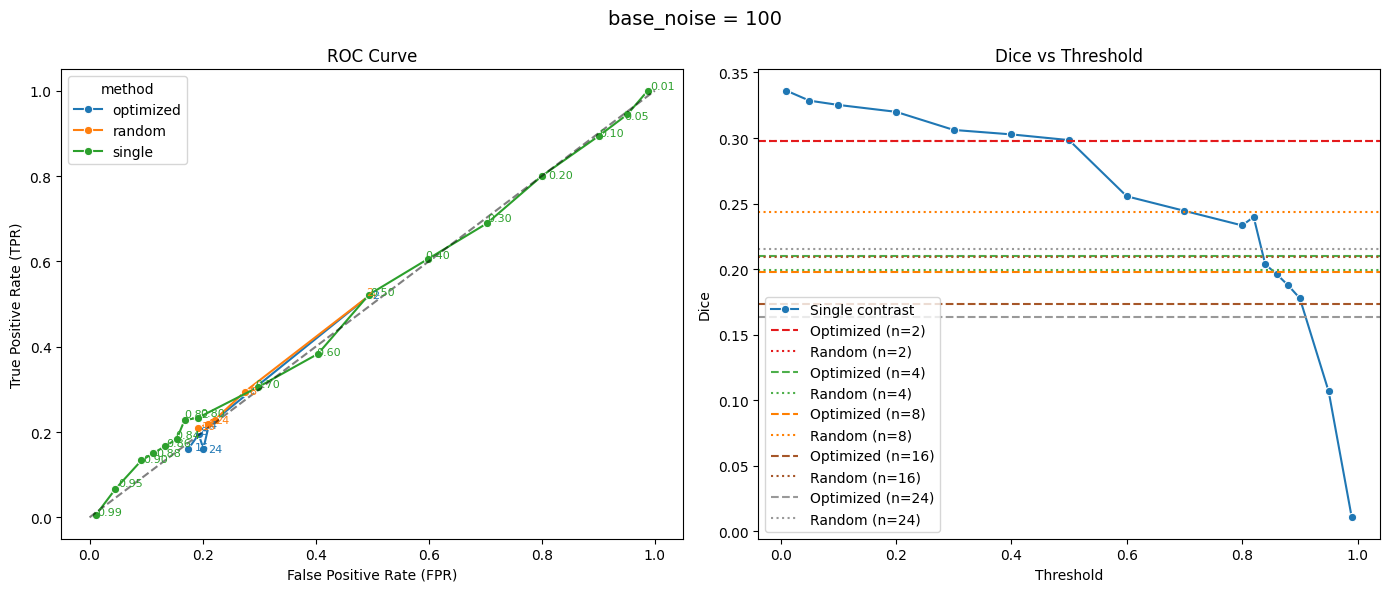

In [7]:
for D_multi, D_random, D_single, noise in results_all:
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"base_noise = {noise}", fontsize=14)

    def avg_roc(df, label):
        avg = df.groupby("n_task" if label != "single" else "threshold")[["TPR", "FPR"]].mean().reset_index()
        avg["method"] = label
        avg["x_label"] = avg["n_task" if label != "single" else "threshold"]
        return avg

    roc_df = pd.concat([
        avg_roc(D_multi, "optimized"),
        avg_roc(D_random, "random"),
        avg_roc(D_single, "single")
    ])

    # --- ROC Curve ---
    palette = sns.color_palette("tab10", 3)
    method_order = ["optimized", "random", "single"]
    roc_ax = axs[0]
    line_objects = sns.lineplot(
        data=roc_df, x="FPR", y="TPR", hue="method",
        hue_order=method_order,
        palette=palette, marker="o", ax=roc_ax
    ).lines

    roc_ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    roc_ax.set_title("ROC Curve")
    roc_ax.set_xlabel("False Positive Rate (FPR)")
    roc_ax.set_ylabel("True Positive Rate (TPR)")

    # Map method to color from plotted lines
    color_map = {method: line.get_color() for method, line in zip(method_order, line_objects)}

    # Annotations
    for _, row in roc_df.iterrows():
        label = f"{row['x_label']:.2f}" if row['method'] == 'single' else f"{int(row['x_label'])}"
        color = color_map[row["method"]]
        jitter_x = 0.005 * np.random.randn()
        jitter_y = 0.005 * np.random.randn()
        roc_ax.text(row["FPR"] + jitter_x, row["TPR"] + jitter_y, label, fontsize=8, color=color)


    # --- Dice Plot ---
    dice_ax = axs[1]

    sns.lineplot(
        data=D_single.groupby("threshold")["dice"].mean().reset_index(),
        x="threshold", y="dice", marker="o", label="Single contrast", ax=dice_ax
    )

    n_tasks = sorted(D_multi["n_task"].unique())
    cmap = cm.get_cmap('Set1', len(n_tasks))
    color_map_task = {n: cmap(i) for i, n in enumerate(n_tasks)}

    for n in n_tasks:
        color = color_map_task[n]

        # Optimized (dashed)
        opt_mean = D_multi[D_multi["n_task"] == n]["dice"].mean()
        dice_ax.axhline(y=opt_mean, linestyle='--', color=color, label=f"Optimized (n={n})")

        # Random (dotted) from D_random!
        rand_mean = D_random[D_random["n_task"] == n]["dice"].mean()
        dice_ax.axhline(y=rand_mean, linestyle=':', color=color, label=f"Random (n={n})")

    dice_ax.set_title("Dice vs Threshold")
    dice_ax.set_xlabel("Threshold")
    dice_ax.set_ylabel("Dice")
    dice_ax.legend()

    plt.tight_layout()
    plt.show()


